# Chapter 15: What an Agent Should Remember: Retrieval, Compression, and Experience

A controller remembers an earlier approval. The text is relevant, concise, and easy to retrieve. It can still be the wrong memory to use if the approval belongs to an older document version. Memory quality therefore includes authority and freshness, not only similarity or token efficiency.

This notebook solves a small declared retrieval allocation. Records consume tokens and contribute additive decision value, but stale records and invalid version-bound authority are excluded first. A separate compression diagnostic checks whether the preferred action survives. The example intentionally gives an obsolete approval a very attractive value, making it impossible to confuse a high relevance score with current permission.

**Outcome:** Choose fresh valid records and inspect action preservation under compression.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For record i, let t_i be token cost, v_i declared decision value, and x_i in{0,1} retrieval status. The finite allocation maximizes sum_i v_i x_i subject to sum_i t_i x_i<=B. Freshness requires now-timestamp_i<=ttl_i. An authority-bearing record also requires its version to equal the current version.

The code uses exact zero-one knapsack dynamic programming over integer budgets. Descending budget updates prevent the same record from being selected repeatedly. Its frontier gives the greatest eligible additive value at every budget from zero to B. These values are supplied judgments, not embedding similarity or empirically learned information gain.

For compression, the implementation compares argmax_a Q_original(a) with argmax_a Q_compressed(a). Equal choices mean this particular decision is preserved. They do not imply the compressed memory retains every fact or supports every future task. Ties follow list order, so a genuine decision-preservation claim should also inspect whether a meaningful action gap remains.

## Apply this to an agent

Memory should preserve the facts needed for the next authorized decision. Retrieve within a token budget, reject stale authority, and test whether compression changes the preferred action. Similarity to a query does not make a record authoritative.

## A calculation you can run

Supply records with token counts, value, timestamps, time-to-live, authority flags, and version identifiers. The function checks numeric domains and rejects a timestamp later than now. It constructs freshness and authority validity before allocating budget. Invalid records remain visible in the returned table rather than disappearing without explanation.

The plot shows the eligible retrieval frontier against token budget. The metrics identify selected and excluded records, used tokens, and compression choices. In the changed case reduce the budget and alter the compressed action values. Predict which record remains affordable and whether the action still matches. The two interventions address separate questions, so report both rather than attributing the entire change to memory quality.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 15
inputs = {'budget': 6,
 'now': 10,
 'current_version': 'v2',
 'records': [{'id': 'review-v2',
              'tokens': 4,
              'decision_value': 8,
              'timestamp': 9,
              'ttl': 3,
              'authority': True,
              'version': 'v2'},
             {'id': 'summary',
              'tokens': 2,
              'decision_value': 3,
              'timestamp': 8,
              'ttl': 5,
              'authority': False,
              'version': 'v1'},
             {'id': 'old-review',
              'tokens': 1,
              'decision_value': 100,
              'timestamp': 9,
              'ttl': 3,
              'authority': True,
              'version': 'v1'}],
 'original_action_values': [4, 6],
 'compressed_action_values': [3, 5]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 15: memory-budget
Which memories deserve a limited retrieval budget, and does compression preserve the decision?
Evidence: constructed teaching example

Calculated quantities:
{
  "retrieved_ids": [
    "review-v2",
    "summary"
  ],
  "retrieval_value": 11.0,
  "tokens_used": 6,
  "excluded_ids": [
    "old-review"
  ],
  "compression_preserves_action": true,
  "original_action": 1,
  "compressed_action": 1
}

Interpretation:
Retrieval optimizes declared decision value among records that satisfy freshness and version-bound authority checks. Compression is checked by the action it preserves.

Assumptions:
- Record values are additive and supplied, not inferred from text similarity.
- Exact finite subset search; no semantic embedding model.

Limitations:
- Preserving one decision vector does not prove sufficiency for every future task.
- Retrieval relevance is not authority.

Execution: completed locally; constructed inputs are not deployment measurements.


At budget 6, review-v2 and summary fit exactly and contribute value 11. Old-review is excluded because its authority belongs to v1, despite its declared value 100 and low token cost. Its timestamp is fresh; freshness alone is therefore insufficient.

Original action values [4,6] and compressed values [3,5] both prefer action 1. With changed budget 2, only summary is retrieved, giving value 3. Changed compressed values [6,5] prefer action 0, so compression no longer preserves the decision. That flag concerns this supplied value comparison; it does not infer which memory sentence caused the reversal.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


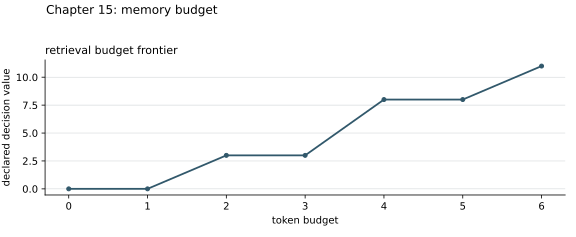

In [3]:
display(SVG(figure_svg(report)))

**Figure 15.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Additive record values can overcount redundant memories. Two records that repeat the same fact may contribute less together than the sum of their isolated values. This implementation declares additivity rather than inventing a submodular or semantic model. If redundancy matters, provide a different valuation experiment.

The authority boundary is equally important. A remembered instruction does not become authorized because it is recent, highly ranked, or compressed into a confident summary. Version checks preserve a limited current-state contract; broader permissions still need a live authority check.

Compression can also preserve today's action while destroying tomorrow's distinction. The argmax diagnostic is task-relative. Test novel decisions and changed state before claiming sufficient memory. Keep excluded-record reasons in the report so token scarcity is not mistaken for intentional retention of unsafe evidence.

Chapter 15: memory-budget
Which memories deserve a limited retrieval budget, and does compression preserve the decision?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "retrieved_ids": [
    "summary"
  ],
  "retrieval_value": 3.0,
  "tokens_used": 2,
  "excluded_ids": [
    "old-review"
  ],
  "compression_preserves_action": false,
  "original_action": 1,
  "compressed_action": 0
}

Interpretation:
Retrieval optimizes declared decision value among records that satisfy freshness and version-bound authority checks. Compression is checked by the action it preserves.

Assumptions:
- Record values are additive and supplied, not inferred from text similarity.
- Exact finite subset search; no semantic embedding model.

Limitations:
- Preserving one decision vector does not prove sufficiency for every future task.
- Retrieval relevance is not authority.

Execution: completed locally; constructed inputs are not deployment measurements.


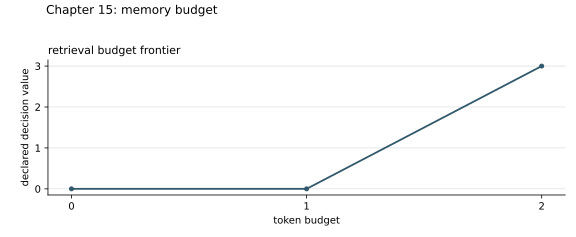

In [4]:
changed_inputs = {'budget': 2,
 'now': 10,
 'current_version': 'v2',
 'records': [{'id': 'review-v2',
              'tokens': 4,
              'decision_value': 8,
              'timestamp': 9,
              'ttl': 3,
              'authority': True,
              'version': 'v2'},
             {'id': 'summary',
              'tokens': 2,
              'decision_value': 3,
              'timestamp': 8,
              'ttl': 5,
              'authority': False,
              'version': 'v1'},
             {'id': 'old-review',
              'tokens': 1,
              'decision_value': 100,
              'timestamp': 9,
              'ttl': 3,
              'authority': True,
              'version': 'v1'}],
 'original_action_values': [4, 6],
 'compressed_action_values': [6, 5]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 15.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case excludes expired even though it is cheap and valuable. Current is fresh, version-valid, and consumes the full budget 3, so it is selected with value 4. Both supplied decision vectors prefer action 0, preserving this action under compression.

To apply this to your own system, attach timestamps and document versions to records when those affect authority. Give decision values an explicit source, such as a constructed study or measured task benefit. A retrieval recommendation should name records to retain, records to exclude, and the evidence needed to justify their values. Use separate trace analysis when memory is trying to promote untrusted data into control.

In [5]:
transfer_inputs = {'budget': 3,
 'now': 20,
 'current_version': 'doc-C',
 'records': [{'id': 'expired',
              'tokens': 1,
              'decision_value': 10,
              'timestamp': 10,
              'ttl': 2,
              'authority': False,
              'version': 'doc-C'},
             {'id': 'current',
              'tokens': 3,
              'decision_value': 4,
              'timestamp': 19,
              'ttl': 3,
              'authority': True,
              'version': 'doc-C'}],
 'original_action_values': [1, 0],
 'compressed_action_values': [2, 1]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 15: memory-budget
Which memories deserve a limited retrieval budget, and does compression preserve the decision?
Evidence: constructed transfer example

Calculated quantities:
{
  "retrieved_ids": [
    "current"
  ],
  "retrieval_value": 4.0,
  "tokens_used": 3,
  "excluded_ids": [
    "expired"
  ],
  "compression_preserves_action": true,
  "original_action": 0,
  "compressed_action": 0
}

Interpretation:
Retrieval optimizes declared decision value among records that satisfy freshness and version-bound authority checks. Compression is checked by the action it preserves.

Assumptions:
- Record values are additive and supplied, not inferred from text similarity.
- Exact finite subset search; no semantic embedding model.

Limitations:
- Preserving one decision vector does not prove sufficiency for every future task.
- Retrieval relevance is not authority.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **budget:** Nonnegative integer token budget up to 10000.
- **now:** Nonnegative current time.
- **current_version:** Current document or state version identifier.
- **records:** At most 20 records. Each has id,tokens:positive integer,decision_value:nonnegative number,timestamp,ttl:nonnegative numbers,authority:boolean,version:string.
- **original_action_values:** Finite values for each original decision alternative.
- **compressed_action_values:** Aligned values after compression.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch15.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 15: memory-budget
Which memories deserve a limited retrieval budget, and does compression preserve the decision?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "retrieved_ids": [
    "current"
  ],
  "retrieval_value": 4.0,
  "tokens_used": 3,
  "excluded_ids": [
    "expired"
  ],
  "compression_preserves_action": true,
  "original_action": 0,
  "compressed_action": 0
}

Interpretation:
Retrieval optimizes declared decision value among records that satisfy freshness and version-bound authority checks. Compression is checked by the action it preserves.

Assumptions:
- Record values are additive and supplied, not inferred from text similarity.
- Exact finite subset search; no semantic embedding model.

Limitations:
- Preserving one decision vector does not prove sufficiency for every future task.
- Retrieval relevance is not authority.

Execution: completed locally; constructed inputs are not deployment measurements.


## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c15-d01"></a>

### Demonstration 1: Records chosen under a token budget

Which records does a limited budget buy once expired and superseded records are screened out, and how does the price of a token change the answer?

![Equation 15.1](../assets/math/f7d464531063a86995f9.svg)

**Symbols and units:** R is the set of records brought into view, m one record, c(m) its size in tokens, and B the token budget. The expected decision value is how much R improves the present decision, in declared units. λ (lambda) is the price of one token in those same units. Net value of a record is its decision value minus λ times its tokens. The arg max picks the set with the largest total. Before any value is counted, a record must be fresh (its age is at most its time to live) and, if it carries authority, bound to the current version.

Each eligible record gets a net value: what it adds to the decision minus what its tokens cost. Equation (15.1) looks for the set of records, no larger than the budget, with the greatest total net value. A record with negative net value is left out even when room remains, and a useful record can be left out because the budget is spent. Records that are expired or tied to an old version are excluded before any value is counted. Similarity to the request is not part of the calculation.

**Use in this chapter:** When a context window is limited, give each candidate record a stated value for the decision at hand and a cost, screen out what is expired or superseded, then keep the set with the best total instead of the closest wording.

**Assumptions:** Values are declared by the designer and add up across records, which overcounts two records that repeat the same fact. The chapter example values the old approval 0 because it is superseded; the thread summary and its value 3 are defined for this reader, and the laboratory cases use their own declared values. A net value of exactly 0 is a tie and is reported as one.

**Predict before running:** In the default case with λ = 0 (budget 6), which records are retrieved?

**Controls you can change:**

- **Case:** `case` accepts 'chapter', 'default', 'changed', 'transfer'.
- **Price of a token, lambda (value units per token):** `lam` accepts 0, 1, 2.

**Source section:** Retrieval is an action under budget.

**Evidence:** constructed teaching example.

Constructed example: the chapter's revocation (2 tokens, value 8) and irrelevant note (value 0), plus the laboratory's default, changed and transfer cases for the memory-budget function; the thread summary and the old approval's value are defined for this reader, and every selection is computed with the laboratory's function.

Prediction choices:

1. old-review alone, because its value is 100
2. review-v2 and summary, for a total of 11
3. all three records

**Boundary of the conclusion:** The context-budget and stale-approval numbers are stipulated for teaching rather than drawn from a deployed system.

**Common wrong turn:** The chapter says the memory problem is not to retrieve the most similar text, and that embedding similarity is a selection score, not a probability of truth or utility. A high declared value on a superseded record does not survive the freshness and version checks.

Records chosen under a token budget
Controls: {"case": "chapter", "lam": 1}
Evidence: constructed teaching example

Calculated quantities:
Chosen by Equation (15.1): Current revocation
Total net value: 6.0
Tokens used: 2 of 2
Excluded before scoring: Old approval
Best sets: 1

Worked steps:
1. Check each record first: it must be fresh (age at most ttl) and any authority record must match version v2.
2. Excluded: Old approval (stale authority (v1, current v2)).
3. Net values: Current revocation 8 - 1 x 2 = 6.0; Thread summary 3 - 1 x 2 = 1.0; Irrelevant note 0 - 1 x 2 = -2.0.
4. Best set within 2 tokens: Current revocation, total 6.0, 2 tokens.

Chapter example. Net value = decision value - lambda x tokens. Current revocation 8 - 1 x 2 = 6.0; Thread summary 3 - 1 x 2 = 1.0; Old approval excluded: stale authority (v1, current v2); Irrelevant note 0 - 1 x 2 = -2.0. Equation (15.1) keeps Current revocation, for a total of 6.0 using 2 of 2 tokens. Thread summary has net value 1.0 but would 

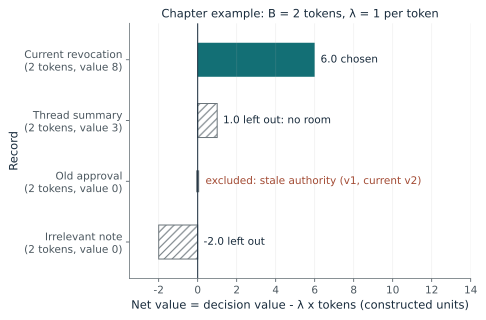

In [8]:
demo_id = 'C15-D01'
demo_controls = {'case': 'chapter', 'lam': 1}
demo_result = run_demo(15, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Case** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Records chosen under a token budget
Controls: {"case": "default", "lam": 1}
Evidence: constructed teaching example

Calculated quantities:
Chosen by Equation (15.1): review-v2, summary
Total net value: 5.0
Tokens used: 6 of 6
Excluded before scoring: old-review
Best sets: 1

Worked steps:
1. Check each record first: it must be fresh (age at most ttl) and any authority record must match version v2.
2. Excluded: old-review (stale authority (v1, current v2)).
3. Net values: review-v2 8 - 1 x 4 = 4.0; summary 3 - 1 x 2 = 1.0.
4. Best set within 6 tokens: review-v2, summary, total 5.0, 6 tokens.

Default case. Net value = decision value - lambda x tokens. review-v2 8 - 1 x 4 = 4.0; summary 3 - 1 x 2 = 1.0; old-review excluded: stale authority (v1, current v2). Equation (15.1) keeps review-v2, summary, for a total of 5.0 using 6 of 6 tokens. old-review is excluded although its declared value is 100 and its timestamp is fresh: a high value cannot buy back an expired or superseded record.

Ass

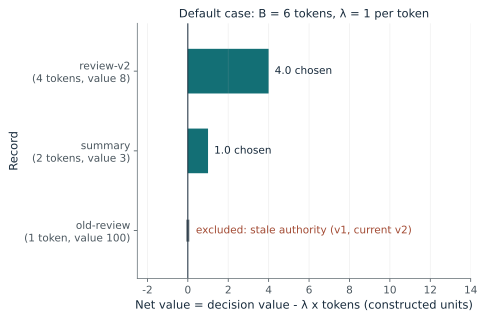

In [9]:
changed_controls = {'case': 'default', 'lam': 1}
changed_demo = run_demo(15, 'C15-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(15, 'C15-D01'):
    state = run_demo(15, 'C15-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "chapter",
      "lam": 0
    },
    "metrics": [
      [
        "Chosen by Equation (15.1)",
        "Current revocation"
      ],
      [
        "Total net value",
        "8.0"
      ],
      [
        "Tokens used",
        "2 of 2"
      ],
      [
        "Excluded before scoring",
        "Old approval"
      ],
      [
        "Best sets",
        "1"
      ]
    ]
  },
  {
    "controls": {
      "case": "chapter",
      "lam": 1
    },
    "metrics": [
      [
        "Chosen by Equation (15.1)",
        "Current revocation"
      ],
      [
        "Total net value",
        "6.0"
      ],
      [
        "Tokens used",
        "2 of 2"
      ],
      [
        "Excluded before scoring",
        "Old approval"
      ],
      [
        "Best sets",
        "1"
      ]
    ]
  },
  {
    "controls": {
      "case": "chapter",
      "lam": 2
    },
    "metrics": [
      [
        "Chosen by Equation (15.1)",
        "Current revocation"


**Check your understanding:** In the transfer case (budget 3, now 20, current version doc-C), which record is retrieved, and what is the total value at λ = 0?

[Answer and worked reasoning](../solutions/ch15.md#demonstration-1). [Matching browser demonstration](../readers/15-memory-budget/reader.html#C15-D01).

<a id="demo-c15-d02"></a>

### Demonstration 2: How much can a summary lose?

If a summary scores each action within epsilon of the full history, how much value can following it lose, and when does that claim stop applying?

![Mathematical relation](../assets/demo-equations/e42eee0dd3301352a215.svg)

**Symbols and units:** ε (epsilon) is the largest error the summary is claimed to make on any action that both the summary and the full history list. Regret is the value of the best action under the full history minus the full-history value of the action the summary picks. The equation block shows the limit: the chapter's claim is that this regret is at most 2 epsilon when the conditions below hold. Values are in declared units.

The summary may undercount the best action by epsilon and overcount a rival by epsilon, so a rival can match or overtake only when the gap is at most 2 epsilon. That is why the regret cannot exceed 2 epsilon, provided every error really is at most epsilon: if the largest error is bigger than the claimed epsilon, the premise fails and the claim is silent. The argument also needs both versions to list the same permitted actions. Switch to the summary that dropped a revocation: the full history no longer permits release (drawn here as a value of -50) while the summary still scores it 10, so the guarantee has nothing to say.

**Use in this chapter:** Before replacing a long history with a short summary, check whether the summary errs only in its scores, or whether it has changed which actions are permitted. Only the first case is covered by the bound.

**Assumptions:** The bound needs a shared way of valuing what comes after the decision and covers only actions both versions list, including the full-history best. The laboratory's cases are one supplied comparison each, so preserving one decision vector does not prove that every future task is preserved. Worst-case errors are placed by hand to show the limit; they are not a claim about any real summary.

**Predict before running:** In the changed case (full values 4 and 6, summary values 6 and 5) with ε = 2, does the summary keep the best action, and is the 2ε claim satisfied?

**Controls you can change:**

- **What the summary did:** `summary` accepts 'worst', 'dropped', 'default', 'changed'.
- **Claimed summary error epsilon:** `epsilon` accepts 1, 2, 3.

**Source section:** Compression that preserves action.

**Evidence:** constructed teaching example.

Constructed example: action values 10, 6 and 3 and an unauthorized release worth -50 are defined for this reader; the 2 epsilon bound is the chapter's, and the laboratory's default and changed compression cases (full values 4 and 6, summary values 3 and 5, then 6 and 5) are checked with its compression comparison.

Prediction choices:

1. It keeps Action 1 and the regret is 0
2. It switches to Action 0, with regret 2 inside the limit 4
3. It switches to Action 0 and the claim is violated

**Boundary of the conclusion:** The compression section's 2ε bound presumes a shared continuation convention and covers only common feasible actions, not actions a summary omits entirely; no particular retrieval system is shown to satisfy it here.

**Common wrong turn:** The chapter says that if the full history has approval but the summary omits a new revocation, the action sets differ and no 2ε claim applies: query the authoritative external state or choose abstention.

How much can a summary lose?
Controls: {"summary": "worst", "epsilon": 1}
Evidence: constructed teaching example

Calculated quantities:
Largest error of the summary: 1.0
Claimed epsilon: 1
Summary follows: Release
Regret of that action: 0.0
Limit 2ε: 2.0
2ε claim: holds: regret within the limit

Worked steps:
1. Full-history values: Release 10, Ask owner 6, Abstain 3.
2. Summary values: Release 9.0, Ask owner 7.0, Abstain 3.0.
3. Largest error on shared actions: 1.0; claimed epsilon 1; premise holds.
4. The summary follows Release.
5. Regret = best full value 10 minus the full value of that action = 0.0.
6. Limit 2 x 1 = 2.0; claim: holds: regret within the limit.

Summary scores: release 10 - 1 = 9.0, ask owner 6 + 1 = 7.0, abstain 3. It still follows release, so regret = 10 - 10 = 0.0, far inside the limit 2 x 1 = 2.0. Every error here is at most epsilon on actions both versions list, which is what the bound requires.

Assumptions: The bound needs a shared way of valuing what comes 

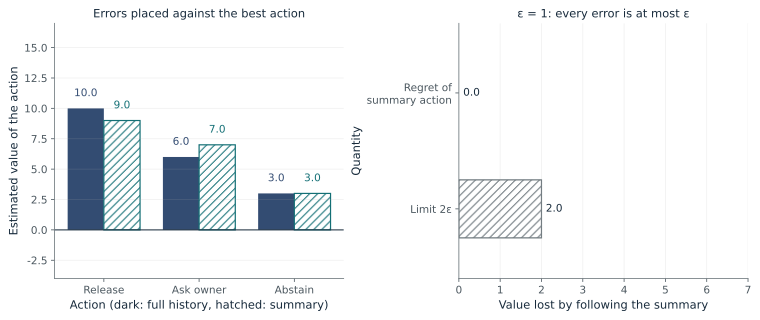

In [11]:
demo_id = 'C15-D02'
demo_controls = {'summary': 'worst', 'epsilon': 1}
demo_result = run_demo(15, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **What the summary did** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

How much can a summary lose?
Controls: {"summary": "dropped", "epsilon": 1}
Evidence: constructed teaching example

Calculated quantities:
Largest error of the summary: 60.0
Claimed epsilon: 1
Summary follows: Release
Regret of that action: 56.0
Limit 2ε: 2.0
2ε claim: does not apply (action sets differ)

Worked steps:
1. Full-history values: Release -50, Ask owner 6, Abstain 3.
2. Summary values: Release 10.0, Ask owner 6.0, Abstain 3.0.
3. The error drawn for release is 60, but the two versions list different permitted actions, so the premise fails.
4. The summary follows Release.
5. Regret = best full value 6 minus the full value of that action = 56.0.
6. Limit 2 x 1 = 2.0; claim: does not apply (action sets differ).

The full history holds a revocation, so releasing now is not permitted; this reader draws that as a value of -50, a loss of 50. The summary kept only the old approval and still scores release at 10, an error of 10 - (-50) = 60, far above epsilon = 1. It follows release

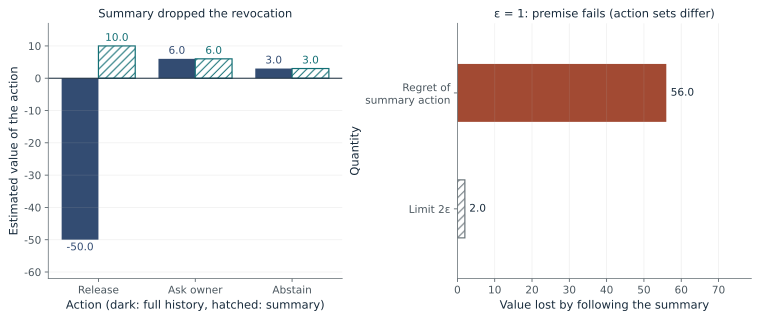

In [12]:
changed_controls = {'summary': 'dropped', 'epsilon': 1}
changed_demo = run_demo(15, 'C15-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(15, 'C15-D02'):
    state = run_demo(15, 'C15-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "summary": "worst",
      "epsilon": 1
    },
    "metrics": [
      [
        "Largest error of the summary",
        "1.0"
      ],
      [
        "Claimed epsilon",
        "1"
      ],
      [
        "Summary follows",
        "Release"
      ],
      [
        "Regret of that action",
        "0.0"
      ],
      [
        "Limit 2ε",
        "2.0"
      ],
      [
        "2ε claim",
        "holds: regret within the limit"
      ]
    ]
  },
  {
    "controls": {
      "summary": "worst",
      "epsilon": 2
    },
    "metrics": [
      [
        "Largest error of the summary",
        "2.0"
      ],
      [
        "Claimed epsilon",
        "2"
      ],
      [
        "Summary follows",
        "Release or Ask owner (tie)"
      ],
      [
        "Regret of that action",
        "0.0 or 4.0"
      ],
      [
        "Limit 2ε",
        "4.0"
      ],
      [
        "2ε claim",
        "holds: regret within the limit"
      ]
    ]
  },
  {
  

**Check your understanding:** If epsilon is 2.5 and the worst-case errors are applied to scores 10 and 6, what are the summary's two scores and the largest possible regret?

[Answer and worked reasoning](../solutions/ch15.md#demonstration-2). [Matching browser demonstration](../readers/15-memory-budget/reader.html#C15-D02).

<a id="demo-c15-d03"></a>

### Demonstration 3: Stale approval is not support

When an old approval is the most similar record, and deletion may reach only some views, which retrieval policy still blocks an unauthorized release?

![Equation 15.1](../assets/math/f7d464531063a86995f9.svg)

**Symbols and units:** Similarity is a score for how closely a record's wording matches the request; it is not a probability of truth. Recency means the newest record. Decision aware means choosing the record with the best net value in Equation (15.1), here with room for one record of 2 tokens and λ = 1 per token. A view is any place a record's content can survive: the visible store, a selection index, a derived summary, a cache, the model context or a downstream copy.

The old approval reads closest to the request, so a similarity ranking retrieves it and releases without permission, even though every retrieved sentence was accurate when written. Recency retrieves the newest record. The decision-aware rule gives the revocation net value 8 - 2 = 6 and the others 0 - 2, so it keeps the revocation; if the revocation cannot be reached, nothing has positive net value and the controller abstains. Deletion that reaches only the visible store leaves derived copies competing; deletion from every view removes the approval but does not choose among the rest.

**Use in this chapter:** Test a memory component by what the controller does next, not only by whether the retrieved text reads well, and query derived views as well as the source store after a deletion.

**Assumptions:** Room for one record, the book's three similarity scores for the approval and the note, and a revocation valued 8 against 0 for the others. The index copy of the approval is assumed to keep the approval's wording and so its similarity; the 0.99 revocation similarity and the note's recency are defined for this reader. Recency fails if the newest record is not the authority, and the decision-aware rule is only as good as the declared values and the authority lookup. 'Correct' means consistent with the chapter's rule that a revoked release must not go ahead.

**Predict before running:** Delete the old approval from the visible store only (a summary index keeps a copy of the same wording). Which policy still releases without permission?

**Controls you can change:**

- **Similarity of the current revocation:** `revocation_similarity` accepts 0.72, 0.99.
- **Can the current authority be reached?:** `authority` accepts 'reachable', 'unreachable'.
- **How far deletion of the old approval reached:** `deletion` accepts 'none', 'store', 'all'.

**Source section:** Stale approval is not support.

**Evidence:** constructed teaching example.

Constructed example: the chapter's similarities 0.98, 0.72 and 0.80 and its values 8 and 0; the other revocation similarity, the unreachable case and the deletion states are defined for this reader, computed with the laboratory's memory-budget function.

Prediction choices:

1. Recency only
2. Similarity only, because the copy still has similarity 0.98
3. None, because the approval was deleted

**Boundary of the conclusion:** The deletion-aware index and conflict-resolution rule appear only as named requirements; building either is left to the implementer.

**Common wrong turn:** The chapter says a high recall score with unauthorized release is a memory-system failure even if every retrieved sentence was historically accurate, and that absence from one query result is not evidence that later agents cannot use a deleted record.

Stale approval is not support
Controls: {"revocation_similarity": 0.72, "authority": "reachable", "deletion": "none"}
Evidence: constructed teaching example

Calculated quantities:
Recency only: Release blocked (correct)
Similarity only: Unauthorized release
Decision aware: Release blocked (correct)

Worked steps:
1. Candidates: old approval (similarity 0.98), note (similarity 0.80), revocation (similarity 0.72).
2. Net values: old approval 0 - 1 x 2 = (-2.0); note 0 - 1 x 2 = (-2.0); revocation 8 - 1 x 2 = 6.0.
3. Decision aware keeps the record with positive net value: release blocked (correct).
4. Similarity only keeps the closest wording, old approval (0.98): unauthorized release.
5. Recency only keeps the newest reachable record, revocation: release blocked (correct).
6. Two reports for Similarity only: the recall report says the retrieved old approval is accurate when it was written; the decision report says: unauthorized release.

Net value with lambda = 1 and 2 tokens per recor

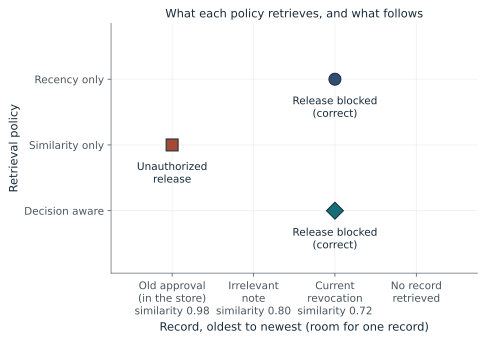

In [14]:
demo_id = 'C15-D03'
demo_controls = {'revocation_similarity': 0.72, 'authority': 'reachable', 'deletion': 'none'}
demo_result = run_demo(15, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Similarity of the current revocation** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Stale approval is not support
Controls: {"revocation_similarity": 0.99, "authority": "reachable", "deletion": "none"}
Evidence: constructed teaching example

Calculated quantities:
Recency only: Release blocked (correct)
Similarity only: Release blocked (correct)
Decision aware: Release blocked (correct)

Worked steps:
1. Candidates: old approval (similarity 0.98), note (similarity 0.80), revocation (similarity 0.99).
2. Net values: old approval 0 - 1 x 2 = (-2.0); note 0 - 1 x 2 = (-2.0); revocation 8 - 1 x 2 = 6.0.
3. Decision aware keeps the record with positive net value: release blocked (correct).
4. Similarity only keeps the closest wording, revocation (0.99): release blocked (correct).
5. Recency only keeps the newest reachable record, revocation: release blocked (correct).
6. Two reports for Similarity only: the recall report says the retrieved revocation is accurate and current; the decision report says: release blocked (correct).

Net value with lambda = 1 and 2 tokens per re

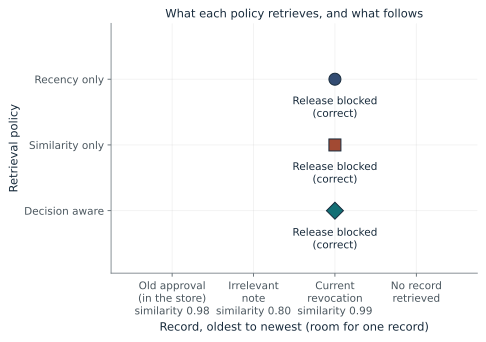

In [15]:
changed_controls = {'revocation_similarity': 0.99, 'authority': 'reachable', 'deletion': 'none'}
changed_demo = run_demo(15, 'C15-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(15, 'C15-D03'):
    state = run_demo(15, 'C15-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "revocation_similarity": 0.72,
      "authority": "reachable",
      "deletion": "none"
    },
    "metrics": [
      [
        "Recency only",
        "Release blocked (correct)"
      ],
      [
        "Similarity only",
        "Unauthorized release"
      ],
      [
        "Decision aware",
        "Release blocked (correct)"
      ]
    ]
  },
  {
    "controls": {
      "revocation_similarity": 0.72,
      "authority": "reachable",
      "deletion": "store"
    },
    "metrics": [
      [
        "Recency only",
        "Release blocked (correct)"
      ],
      [
        "Similarity only",
        "Unauthorized release"
      ],
      [
        "Decision aware",
        "Release blocked (correct)"
      ]
    ]
  },
  {
    "controls": {
      "revocation_similarity": 0.72,
      "authority": "reachable",
      "deletion": "all"
    },
    "metrics": [
      [
        "Recency only",
        "Release blocked (correct)"
      ],
      [
        "Si

**Check your understanding:** A new record has value 5 and 2 tokens, with λ = 3. What is its net value, and is it retrieved?

[Answer and worked reasoning](../solutions/ch15.md#demonstration-3). [Matching browser demonstration](../readers/15-memory-budget/reader.html#C15-D03).

<a id="demo-c15-d04"></a>

### Demonstration 4: A record that may no longer be current

How likely must a record be to still be current before it is worth its tokens?

![Mathematical relation](../assets/demo-equations/ce196bce1a831ce918c9.svg)

**Symbols and units:** p is the probability that the record is still current. A current record is worth 8 decision-value units and an invalid one is worth 0. The record costs 1 token, and λ (lambda) is the price of a token in the same units. The expected value is p x 8 + (1 - p) x 0, and the net value subtracts λ times the tokens.

A record's status, expiry and version tell a controller how likely the record is to still hold. That probability scales its value: at p = 0.6 the expected value is 4.8, and one token at λ = 1 leaves a net of 3.8. The same record at a higher token price needs a higher p, and in this model, where a record is worth 8 only while it is current, a deleted or expired record has p = 0 and cannot pay for itself.

**Use in this chapter:** Record who wrote an item, when it was seen, and when it expires, so the controller can estimate how likely it is to be current and charge retrieval accordingly.

**Assumptions:** One record, valued 8 if current and 0 if invalid, with no partial credit. The probability p is assumed to come from the record's fields; an honest estimate of it is the hard part and is not shown here. A record that can authorize an action should need a much higher p than this simple price implies.

**Predict before running:** At λ = 4, where does the net value cross zero? That value of p is the break-even probability.

**Controls you can change:**

- **Probability the record is still current, p:** `p_current` accepts 0.25, 0.5, 0.6, 0.8.
- **Price of a token, lambda:** `lam` accepts 1, 2, 4.

**Source section:** Exercises.

**Evidence:** constructed teaching example.

Constructed example: the chapter's Exercise 1 values (value 8, one token, probability 0.6, λ = 1); the other probabilities and token prices are defined for this reader.

Prediction choices:

1. p = 0.25
2. p = 0.5
3. p = 0.8

**Common wrong turn:** The chapter says broad durable knowledge may be useful but broad durable authority is dangerous: the more a record can authorize, the shorter its expiry and the stronger its required provenance should be.

A record that may no longer be current
Controls: {"p_current": 0.6, "lam": 1}
Evidence: constructed teaching example

Calculated quantities:
Expected value: 4.80
Token cost: 1.00
Net value: 3.80
Break-even p: 0.125
Decision: Retrieve

Worked steps:
1. A current record is worth 8 and an invalid one 0; it costs 1 token at lambda 1.
2. Expected value = p x 8 + (1 - p) x 0 = 0.60 x 8 + 0.40 x 0 = 4.80.
3. Token cost = lambda x tokens = 1 x 1 = 1.00.
4. Net value = 4.80 - 1.00 = 3.80.
5. Break-even p = cost / value = 1.00 / 8 = 0.125; decision: Retrieve.

Expected value = 0.60 x 8 + 0.40 x 0 = 4.80. Net value = 4.80 - 1 x 1 = 3.80. Break-even p = 1 x 1 / 8 = 0.125. The net value is positive, so the record is worth retrieving (p is above the break-even 0.125). In this model a record is worth 8 only while it is current, so a deleted, expired or superseded one has p = 0: its expected value is 0 x 8 + 1 x 0 = 0 and its net value is (-1.00): the life-cycle fields exist to move p, and the rule th

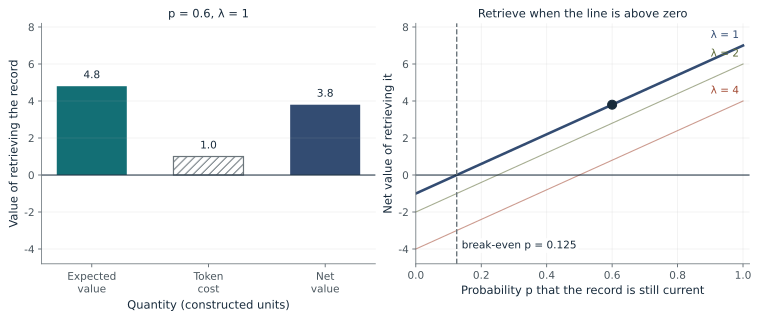

In [17]:
demo_id = 'C15-D04'
demo_controls = {'p_current': 0.6, 'lam': 1}
demo_result = run_demo(15, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Probability the record is still current, p** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A record that may no longer be current
Controls: {"p_current": 0.25, "lam": 1}
Evidence: constructed teaching example

Calculated quantities:
Expected value: 2.00
Token cost: 1.00
Net value: 1.00
Break-even p: 0.125
Decision: Retrieve

Worked steps:
1. A current record is worth 8 and an invalid one 0; it costs 1 token at lambda 1.
2. Expected value = p x 8 + (1 - p) x 0 = 0.25 x 8 + 0.75 x 0 = 2.00.
3. Token cost = lambda x tokens = 1 x 1 = 1.00.
4. Net value = 2.00 - 1.00 = 1.00.
5. Break-even p = cost / value = 1.00 / 8 = 0.125; decision: Retrieve.

Expected value = 0.25 x 8 + 0.75 x 0 = 2.00. Net value = 2.00 - 1 x 1 = 1.00. Break-even p = 1 x 1 / 8 = 0.125. The net value is positive, so the record is worth retrieving (p is above the break-even 0.125). In this model a record is worth 8 only while it is current, so a deleted, expired or superseded one has p = 0: its expected value is 0 x 8 + 1 x 0 = 0 and its net value is (-1.00): the life-cycle fields exist to move p, and the rule t

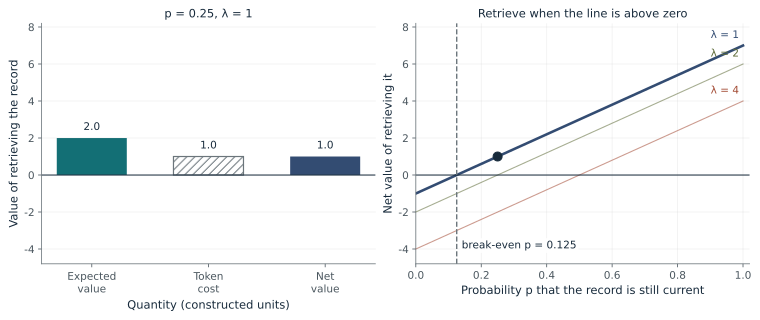

In [18]:
changed_controls = {'p_current': 0.25, 'lam': 1}
changed_demo = run_demo(15, 'C15-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(15, 'C15-D04'):
    state = run_demo(15, 'C15-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "p_current": 0.25,
      "lam": 1
    },
    "metrics": [
      [
        "Expected value",
        "2.00"
      ],
      [
        "Token cost",
        "1.00"
      ],
      [
        "Net value",
        "1.00"
      ],
      [
        "Break-even p",
        "0.125"
      ],
      [
        "Decision",
        "Retrieve"
      ]
    ]
  },
  {
    "controls": {
      "p_current": 0.25,
      "lam": 2
    },
    "metrics": [
      [
        "Expected value",
        "2.00"
      ],
      [
        "Token cost",
        "2.00"
      ],
      [
        "Net value",
        "0.00"
      ],
      [
        "Break-even p",
        "0.250"
      ],
      [
        "Decision",
        "tie"
      ]
    ]
  },
  {
    "controls": {
      "p_current": 0.25,
      "lam": 4
    },
    "metrics": [
      [
        "Expected value",
        "2.00"
      ],
      [
        "Token cost",
        "4.00"
      ],
      [
        "Net value",
        "-2.00"
      ],
   

**Check your understanding:** A record is worth 10 if current and 0 if invalid, costs 2 tokens, with λ = 1 and p = 0.3. What is its net value?

[Answer and worked reasoning](../solutions/ch15.md#demonstration-4). [Matching browser demonstration](../readers/15-memory-budget/reader.html#C15-D04).

## Questions

1. Why exclude old-review?

2. What is default retrieval value?

3. Does action preservation prove all future information survives?

Answers: [separate solutions](../solutions/ch15.md). Try the calculation before opening them.

## Summary

Memory selection is a decision under cost, freshness, and authority. Exact knapsack allocation chooses among eligible records; action comparison checks a limited compression property. The obsolete approval is excluded despite its high value, the changed budget reduces retrieval, and changed compression reverses the action. These calculations do not perform semantic retrieval or establish universal sufficiency. Preserve the valuation and version contract whenever memory influences an action.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-15-memory-budget`](../skills/maa-15-memory-budget/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 15.1

![Equation 15.1](../assets/math/f7d464531063a86995f9.svg)

Equation (15.1) selects records by expected decision value under a stated context budget.

Include records only when expected decision improvement exceeds the decision-value-priced token cost within budget.

LaTeX source, preserved for inspection:

```latex
R^\star\in\arg\max_{R:\,\sum_{m\in R}c(m)\le B}
\left\{\operatorname E[\text{decision value}\mid R]-\lambda\sum_{m\in R}c(m)\right\}.
\tag{15.1}
```